In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [13]:
# Read config file
config = load_config("conf.yaml")

# Choose results path
res_path = Path("results_0.1")

# Read baseline BN
bn_base = gum.loadBN(config["bn_base_path"])
confs = get_confs(bn_base)

# Read sample sizes and repetitions
sizes_dict = config["s_sizes"]
sizes = [
    int(x) for x in np.arange(sizes_dict["min"], sizes_dict["max"], sizes_dict["step"])
]
n_reps = config["n_repetitions"]

# Read results, if any
try:
    df_tot = pd.read_csv(res_path / f"df_tot.csv", index_col=0)
    res_flag = True
except:
    res_flag = False

In [14]:
## Compute results
if not res_flag:
    df_list = []

    # For each repetition ...
    for rep in tqdm(range(n_reps)):

        # ... read the vector of results across all sample sizes, ...
        bn_list = []
        idm_list = []
        mos_list = []
        for n in sizes:
            base_path = res_path / f"ss{n}"

            # BN
            bn = gum.loadBN(f"{base_path}/{rep}-bn.bif")
            bn_list.append(bn)

            # CN
            idm_bn_min = gum.loadBN(f"{base_path}/{rep}-idm_bn_min.bif")
            idm_bn_max = gum.loadBN(f"{base_path}/{rep}-idm_bn_max.bif")
            idm_list.append((idm_bn_min, idm_bn_max))

            # Mosaic
            mos_bn_min = gum.loadBN(f"{base_path}/{rep}-mos_bn_min.bif")
            mos_bn_max = gum.loadBN(f"{base_path}/{rep}-mos_bn_max.bif")
            mos_list.append((mos_bn_min, mos_bn_max))

        # ... and, for each, compute JSD against bn_base
        res = pd.DataFrame({"size": sizes})
        n_bns = 10

        for label in ["idm", "mos"]:

            min_list, max_list, mean_list = [], [], []      
            list_str = f"{label}_list"
            
            for i in range(len(res)):

                # Choose the CN
                bn_min, bn_max = eval(list_str)[i]

                # Vertices (for max JSD)
                vertices_bns = vertices_cn(bn_min, bn_max, n_bns=n_bns)

                # Inner points (for min JSD)
                sampled_bns = sample_from_cn(bn_min, bn_max, n_bns=n_bns)

                # All BNs
                all_bns = vertices_bns + sampled_bns

                # Results
                results = jsd_bounds_from_samples(bn_base, all_bns, target="joint")
                min_list.append(results["min"])
                max_list.append(results["max"])
                mean_list.append(results["mean"])

            res[f"{label}_min"] = min_list
            res[f"{label}_max"] = max_list
            res[f"{label}_mean"] = mean_list

        mle_list = []
        for i in range(len(res)):
            bn = bn_list[i]
            mle_list.append(jsd_bn(bn_base, bn, target="joint"))

        res["mle"] = mle_list

        df_list.append(res)

    # Save results
    df_tot = df_list[0]
    for df in df_list[1:]:
        df_tot = pd.concat((df_tot, df), axis=0)
    df_tot.to_csv(res_path / f"df_tot.csv")

In [15]:
df_mean = df_tot.groupby(["size"], as_index=False).mean()
df_mean

,size,idm_min,idm_max,idm_mean,mos_min,mos_max,mos_mean,mle
0,50,0.522672,0.638591,0.572586,0.165677,0.641368,0.476951,0.628593
1,100,0.568709,0.651079,0.608792,0.153722,0.654460,0.475746,0.652085
2,150,0.586810,0.649473,0.615070,0.118272,0.652135,0.483455,0.649134
3,200,0.593027,0.650992,0.621332,0.144794,0.652785,0.475014,0.648647
4,250,0.607949,0.650930,0.626320,0.096631,0.652515,0.466028,0.652413
5,300,0.614993,0.649191,0.631280,0.112713,0.654473,0.470441,0.653571
6,350,0.616128,0.650769,0.634955,0.084259,0.657160,0.465181,0.654947
7,400,0.621940,0.655673,0.637704,0.090350,0.659124,0.471261,0.654736
8,450,0.622386,0.652992,0.637537,0.105400,0.657246,0.471657,0.654523
9,500,0.621780,0.648545,0.633885,0.101968,0.652170,0.473665,0.647772


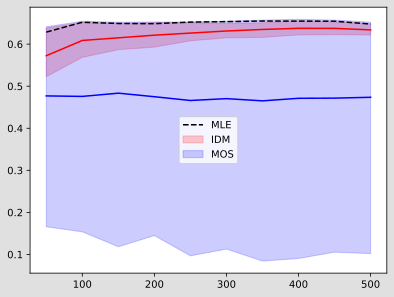

In [16]:
# Plot 
plt.plot(df_mean["size"], df_mean["mle"], "--", color="black", label="MLE")
plt.fill_between(df_mean["size"], df_mean["idm_min"], df_mean["idm_max"], color="red", alpha=.2, label="IDM")
plt.plot(df_mean["size"], df_mean["idm_mean"], color="red")
plt.fill_between(df_mean["size"], df_mean["mos_min"], df_mean["mos_max"], color="blue", alpha=.2, label="MOS")
plt.plot(df_mean["size"], df_mean["mos_mean"], color="blue")


plt.legend(loc="best")
plt.show()